In [1]:
import os
import sys
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision.models import vit_l_16, ViT_L_16_Weights
import torchvision.transforms as transforms
from sklearn.model_selection import GroupShuffleSplit
from torch.optim.lr_scheduler import CosineAnnealingLR

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, roc_curve
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
base_path = Path("/kaggle/input/faceswap-faces/")
batch_size = 4

In [3]:
df = pd.read_csv(base_path / "processed_metadata.csv")
df.head()

,video_id,frame_id,label,filepath
0,437,0,REAL,processed_frames/original/437/437_0000.jpg
1,437,1,REAL,processed_frames/original/437/437_0001.jpg
2,437,2,REAL,processed_frames/original/437/437_0002.jpg
3,437,3,REAL,processed_frames/original/437/437_0003.jpg
4,437,4,REAL,processed_frames/original/437/437_0004.jpg


In [4]:
video_labels = df.groupby('video_id')['label'].first().reset_index()
video_labels

,video_id,label
0,000,REAL
1,000_003,FAKE
2,001,REAL
3,001_870,FAKE
4,002,REAL
...,...,...
1995,997_040,FAKE
1996,998,REAL
1997,998_561,FAKE
1998,999,REAL


In [5]:
video_labels.value_counts()

video_id  label
999_960   FAKE     1
000       REAL     1
000_003   FAKE     1
001       REAL     1
001_870   FAKE     1
                  ..
009_027   FAKE     1
010       REAL     1
010_005   FAKE     1
011       REAL     1
011_805   FAKE     1
Name: count, Length: 2000, dtype: int64

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=69)
train_idx, temp_idx = next(gss.split(video_labels, video_labels['label'], groups=video_labels['video_id']))

train_videos = video_labels.iloc[train_idx]
temp_videos = video_labels.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=69)
val_idx, test_idx = next(gss2.split(temp_videos, temp_videos['label'], groups=temp_videos['video_id']))

val_videos = temp_videos.iloc[val_idx]
test_videos = temp_videos.iloc[test_idx]

train_df = df[df['video_id'].isin(train_videos['video_id'])]
val_df = df[df['video_id'].isin(val_videos['video_id'])]
test_df = df[df['video_id'].isin(test_videos['video_id'])]

train_df

,video_id,frame_id,label,filepath
0,437,0,REAL,processed_frames/original/437/437_0000.jpg
1,437,1,REAL,processed_frames/original/437/437_0001.jpg
2,437,2,REAL,processed_frames/original/437/437_0002.jpg
3,437,3,REAL,processed_frames/original/437/437_0003.jpg
4,437,4,REAL,processed_frames/original/437/437_0004.jpg
...,...,...,...,...
99840,772_708,45,FAKE,processed_frames/faceswap/772_708/772_708_0045...
99841,772_708,46,FAKE,processed_frames/faceswap/772_708/772_708_0046...
99842,772_708,47,FAKE,processed_frames/faceswap/772_708/772_708_0047...
99843,772_708,48,FAKE,processed_frames/faceswap/772_708/772_708_0048...


In [7]:
print("Train/Val/Test split summary:")
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())


Train/Val/Test split summary:
label
FAKE    35349
REAL    34648
Name: count, dtype: int64
label
REAL    7500
FAKE    7500
Name: count, dtype: int64
label
REAL    7849
FAKE    7149
Name: count, dtype: int64


In [8]:
train_vids = set(train_df['video_id'].unique())
val_vids = set(val_df['video_id'].unique())
test_vids = set(test_df['video_id'].unique())

print("Train∩Val:", len(train_vids & val_vids))
print("Train∩Test:", len(train_vids & test_vids))
print("Val∩Test:", len(val_vids & test_vids))

train_files = set(train_df['filepath'])
val_files   = set(val_df['filepath'])
print("Common files train/val:", len(train_files & val_files))

Train∩Val: 0
Train∩Test: 0
Val∩Test: 0
Common files train/val: 0


In [9]:
class DeepfakeDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.df = data
        self.seq_length = seq_length
        self.videos = data['video_id'].unique()

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        vid = self.videos[idx]
        frames = self.df[self.df['video_id'] == vid]
        if len(frames) == 0:
            print(f"[WARN] Label {frames['label'][0]} Video {vid} has 0 frames in DataFrame")

        imgs = [Image.open(f"/kaggle/input/faceswap-faces/{fp}").convert('RGB') for fp in frames['filepath']]
        imgs = [self.transform(i) for i in imgs]
        imgs = torch.stack(imgs)
        imgs = self._add_padding(imgs)
        label = 1 if frames['label'].iloc[0] == 'FAKE' else 0
        return imgs, torch.tensor(label), vid

    def transform(self, img):
        if img.size != (224, 224):
            img = img.resize((224, 224))
        img_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomResizedCrop(224,scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
        ])
        torch_tensor = img_transform(img)
        return torch_tensor

    def _add_padding(self, images):
        padding_needed = self.seq_length - images.size(0)
        if padding_needed > 0:
            pad_tensor = torch.zeros(padding_needed, 3, 224, 224)
            images_tensor = torch.cat((images, pad_tensor), dim=0)
            return images_tensor
        return images


In [10]:
train_dataset = DeepfakeDataset(train_df)
val_dataset = DeepfakeDataset(val_df)
test_dataset = DeepfakeDataset(test_df)


In [11]:
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)


In [12]:
class TemporalStem(nn.Module):
    def __init__(self, in_channels=3, out_channels=64):
        super(TemporalStem, self).__init__()
        self.conv3d = nn.Conv3d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=(3, 7, 7),  # temporal, height, width
            stride=(1, 2, 2),
            padding=(1, 3, 3)
        )
        self.bn = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        # Input: (B, C, T, H, W)
        x = self.conv3d(x)
        x = self.bn(x)
        x = self.relu(x)
        return x  # (B, 64, T, H/2, W/2)

In [13]:
VIT_FEATURE_DIM = 1024     # ViT-L/16 feature dimension
LSTM_HIDDEN_SIZE = 512    # Hidden size for the LSTM layer
LSTM_NUM_LAYERS = 2       # Number of layers in the LSTM

class DetectionModel(nn.Module):
    def __init__(self, num_classes=2, hidden_size=LSTM_HIDDEN_SIZE, num_layers=LSTM_NUM_LAYERS):
        super(DetectionModel, self).__init__()
        self.vit = vit_l_16(weights=ViT_L_16_Weights.IMAGENET1K_V1)
        
        # Freeze ViT weights (optional but recommended for feature extraction)
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.vit.encoder.layers[-1].parameters():
            param.requires_grad = True
            
        # Replace the final classification head with an identity layer 
        # to get the raw feature vector (768 dimensions) before the classifier.
        self.vit.heads.head = nn.Identity() 

        
        # 2. LSTM for Temporal Sequence Modeling
        # input_size is the feature dimension from the ViT (768)
        self.lstm = nn.LSTM(
            input_size=VIT_FEATURE_DIM,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,  # Tensors will be (batch_size, seq_len, features)
            bidirectional=True
        )

        num_heads = 4
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_size * 2,  # Total dimension from bidirectional LSTM
            num_heads=num_heads,        # Number of parallel heads
            batch_first=True            # IMPORTANT: Set this for LSTM output
        )

        
        # 3. Final Classifier Head
        # It takes the hidden state of the final layer of the LSTM.
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, 1)
        )

    def forward(self, x):
        # 1. Prepare for ViT (Per-Frame Processing)
        # x shape: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        
        # Flatten (B, T) into a single pseudo-batch dimension: (B * T, C, H, W)
        x_flat = x.reshape(B * T, C, H, W)
        vit_features_flat = self.vit(x_flat)

        
        # 3. Prepare for LSTM (Sequence Re-formation)
        # Reshape features back into a sequence: (B, T, VIT_FEATURE_DIM)
        lstm_input = vit_features_flat.reshape(B, T, VIT_FEATURE_DIM)
        
        # 4. Sequence Modeling
        # h_n shape: (num_layers, B, hidden_size)
        lstm_out, _ = self.lstm(lstm_input)
        attn_output, _ = self.multihead_attn(lstm_out, lstm_out, lstm_out)
        context = torch.mean(attn_output, dim=1)
        # h_n_cat = torch.cat(h_n[-2], h_n[-1], dim=1)
        # 5. Classification
        # Get the hidden state of the *last* layer (h_n[-1]) for final prediction
        final_output = self.classifier(context)        # Output shape: (B, num_classes)
        
        return final_output

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ", device)

model = DetectionModel()
if device == "cuda":
    model = model.to(device)

Using device:  cuda


Downloading: "https://download.pytorch.org/models/vit_l_16-852ce7e3.pth" to /root/.cache/torch/hub/checkpoints/vit_l_16-852ce7e3.pth
100%|██████████| 1.13G/1.13G [00:05<00:00, 211MB/s]


In [15]:
num_epochs = 18
criterion = nn.BCEWithLogitsLoss(pos_weight=None, reduction='mean')  # More stable for binary tasks
optimizer = optim.AdamW([
    {"params": model.vit.encoder.layers[-1].parameters(), "lr": 1e-5},
    {"params": model.lstm.parameters()},
    {"params": model.classifier.parameters()}
], lr=1e-4, weight_decay=5e-5)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr = 1e-4, steps_per_epoch=len(train_loader), epochs=num_epochs)

In [16]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, verbose=False):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss


In [17]:
scaler = torch.amp.GradScaler('cuda')
early_stopping = EarlyStopping(patience=7, verbose=True)

train_losses = []
val_losses = []
val_accuracies = []


for epoch in range(num_epochs):
    print("\n" + "="*50)
    print(f"Running Epoch: {epoch+1}/{num_epochs}")
    print("="*50)
    
    # ------------------
    # 1. Training Phase (Sequence-level)
    # ------------------
    model.train()
    train_loss = 0
    
    # imgs shape: (B, T, C, H, W), labels shape: (B), _ (vids)
    for imgs, labels, _ in tqdm(train_loader, desc="Training", file=sys.stdout):
        
        # Move video sequence batch to device
        imgs = imgs.to(device)
        labels = labels * 0.9 + 0.05
        
        # Move and format labels: (B) -> (B, 1) float for BCEWithLogitsLoss
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        
        # Autocast enables mixed precision for the forward pass
        with torch.amp.autocast(device):
            # Forward pass: model expects (B, T, C, H, W) and outputs (B, 1)
            outputs = model(imgs) 
            loss = criterion(outputs, labels)

        # Scale loss, backpropagate, and update
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    
    # Step the learning rate scheduler after the epoch
    scheduler.step()
    
    # ------------------
    # 2. Validation Phase (Sequence-level)
    # ------------------
    model.eval()
    per_video_rows = []
    val_loss = 0
    
    with torch.no_grad():
        for imgs, labels, vids in val_loader:
            B, _, _, _, _ = imgs.shape
            
            # Pass the entire sequence batch (B, T, C, H, W) to the model
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            # Forward pass, outputs are logits (B, 1)
            outputs = model(imgs) 
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            
            # Apply sigmoid to get video prediction probabilities and flatten (B,)
            video_preds = torch.sigmoid(outputs).cpu().numpy().ravel()
            
            for i in range(B):
                per_video_rows.append({
                    'video_id': vids[i],
                    # Direct score from the model's output
                    'pred': float(video_preds[i]), 
                    'label': int(labels[i].item())
                })
    avg_val_loss = val_loss / len(val_loader)
    
    # --- Evaluation ---
    video_df_pred = pd.DataFrame(per_video_rows)
    # Only keep one prediction per video, although the current loader only provides one.
    video_df_pred = video_df_pred.drop_duplicates(subset='video_id') 
    
    # Ensure there are enough samples and both classes for meaningful metrics
    if len(video_df_pred) > 1 and len(video_df_pred['label'].unique()) > 1:
        auc = roc_auc_score(video_df_pred['label'], video_df_pred['pred'])
    else:
        auc = 0.0
        print("Warning: Insufficient data for AUC calculation.")

    acc = accuracy_score(video_df_pred['label'], (video_df_pred['pred'] > 0.5).astype(int))

    early_stopping(avg_val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

    train_losses.append(avg_train_loss) 
    val_losses.append(avg_val_loss)
    val_accuracies.append(acc)

    if (epoch + 1) == 3:
        for param in model.vit.encoder.layers[-1].parameters():
            param.requires_grad = True

        optimizer = optim.AdamW([
            {"params": model.vit.encoder.layers[-1].parameters(), "lr": 1e-5},
            {"params": model.lstm.parameters()},
            {"params": model.classifier.parameters()}
        ], lr=1e-4, weight_decay=5e-5)
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr = 1e-4, steps_per_epoch=len(train_loader), epochs=num_epochs)
                
    # ------------------
    # 3. Epoch Summary
    # ------------------
    print("\n" + "*"*60)
    print(f"Epoch {epoch+1} Summary:")
    print(f"| Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {auc:.4f} | Val Acc: {acc:.4f} |")
    # print("\nPrediction Score Distribution:")
    # print(video_df_pred['pred'].describe().to_string())
    print("\n" + "*"*60)


Running Epoch: 1/18
Training: 100%|██████████| 350/350 [24:35<00:00,  4.22s/it]
Validation loss decreased (inf --> 0.689910). Saving model...

************************************************************
Epoch 1 Summary:
| Train Loss: 0.6912 | Val Loss: 0.6899 | Val AUC: 0.6436 | Val Acc: 0.5700 |

************************************************************

Running Epoch: 2/18
Training: 100%|██████████| 350/350 [24:30<00:00,  4.20s/it]
Validation loss decreased (0.689910 --> 0.682107). Saving model...

************************************************************
Epoch 2 Summary:
| Train Loss: 0.6864 | Val Loss: 0.6821 | Val AUC: 0.6652 | Val Acc: 0.5500 |

************************************************************

Running Epoch: 3/18
Training: 100%|██████████| 350/350 [24:30<00:00,  4.20s/it]
Validation loss decreased (0.682107 --> 0.638606). Saving model...

************************************************************
Epoch 3 Summary:
| Train Loss: 0.6662 | Val Loss: 0.6386 | Va


************************************************************
Test Summary:
| Test Loss: 0.2401 | Test AUC: 0.9695 | Test Acc: 0.9067 |

Classification Report:
              precision    recall  f1-score   support

        Real       0.91      0.92      0.91       157
        Fake       0.91      0.90      0.90       143

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300

************************************************************


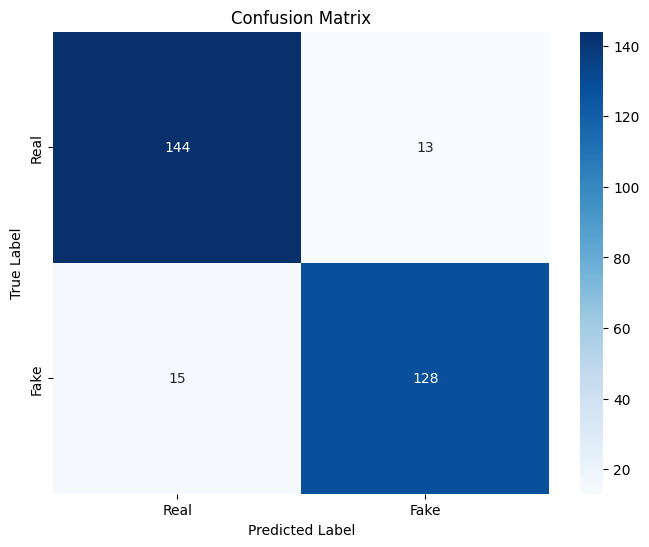

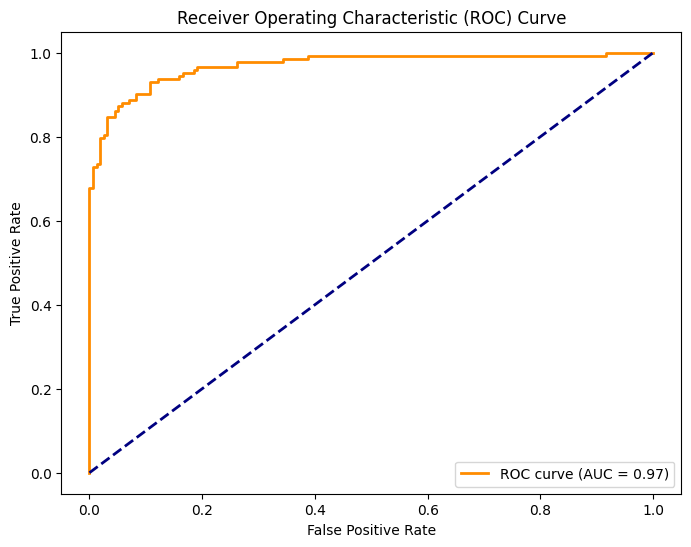

In [18]:
def test_model(model):
    model.eval()
    per_video_rows = []
    test_loss = 0
    
    with torch.no_grad():
        for imgs, labels, vids in test_loader:
            B, _, _, _, _ = imgs.shape
            
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            video_preds = torch.sigmoid(outputs).cpu().numpy().ravel()
            
            for i in range(B):
                per_video_rows.append({
                    'video_id': vids[i],
                    'pred': float(video_preds[i]),
                    'label': int(labels[i].item())
                })
    
    avg_test_loss = test_loss / len(test_loader)
    
    # --- Evaluation ---
    video_df_pred = pd.DataFrame(per_video_rows).drop_duplicates(subset='video_id')
    
    if len(video_df_pred) > 1 and len(video_df_pred['label'].unique()) > 1:
        auc = roc_auc_score(video_df_pred['label'], video_df_pred['pred'])
    else:
        auc = 0.0
        print("Warning: Insufficient data for AUC calculation.")

    true_labels = video_df_pred['label']
    binary_predictions = (video_df_pred['pred'] > 0.5).astype(int)
    acc = accuracy_score(true_labels, binary_predictions)
    report = classification_report(true_labels, binary_predictions, target_names=['Real', 'Fake'])

    # --- Print Summary ---
    print("\n" + "*"*60)
    print("Test Summary:")
    print(f"| Test Loss: {avg_test_loss:.4f} | Test AUC: {auc:.4f} | Test Acc: {acc:.4f} |")
    print("\nClassification Report:")
    print(report)
    print("*"*60)

    # --- Plot Confusion Matrix ---
    cm = confusion_matrix(true_labels, binary_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # --- Plot ROC Curve ---
    fpr, tpr, _ = roc_curve(true_labels, video_df_pred['pred'])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# --- Run the test function ---
test_model(model)

In [19]:
torch.save(model.state_dict(), "model_state.pth")


************************************************************
Test Summary:
| Test Loss: 0.2299 | Test AUC: 0.9701 | Test Acc: 0.9200 |

Classification Report:
              precision    recall  f1-score   support

        Real       0.90      0.96      0.93       157
        Fake       0.95      0.88      0.91       143

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

************************************************************


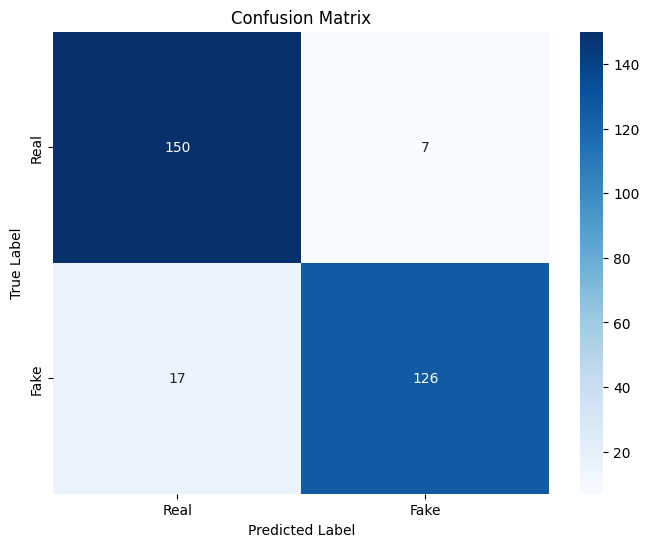

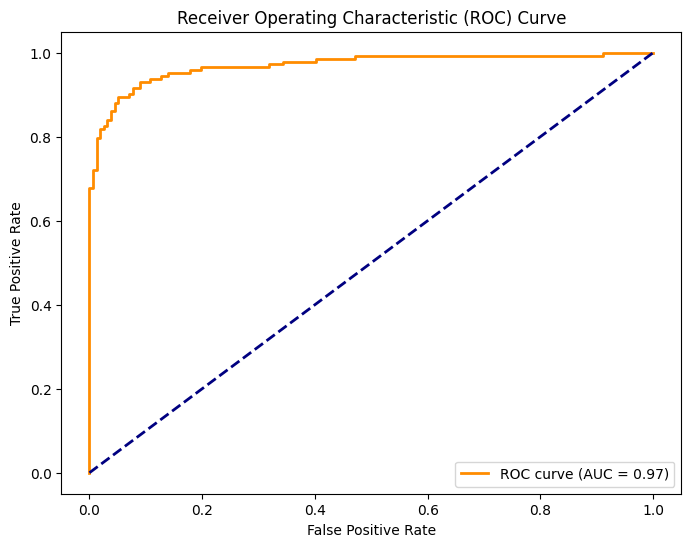

In [20]:
# Create a new instance of the model
model2 = DetectionModel()

# Load the saved state dictionary
checkpoint_dict = torch.load("checkpoint.pt")

# Load the state dict into the model IN-PLACE
model2.load_state_dict(checkpoint_dict)

# Now, move the model to the correct device
if device == "cuda":
    model2 = model2.to(device)

# Test the model
test_model(model2)

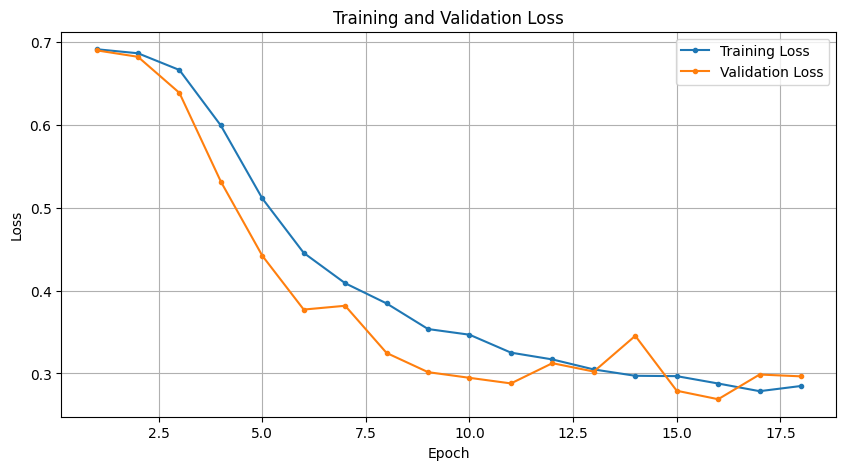

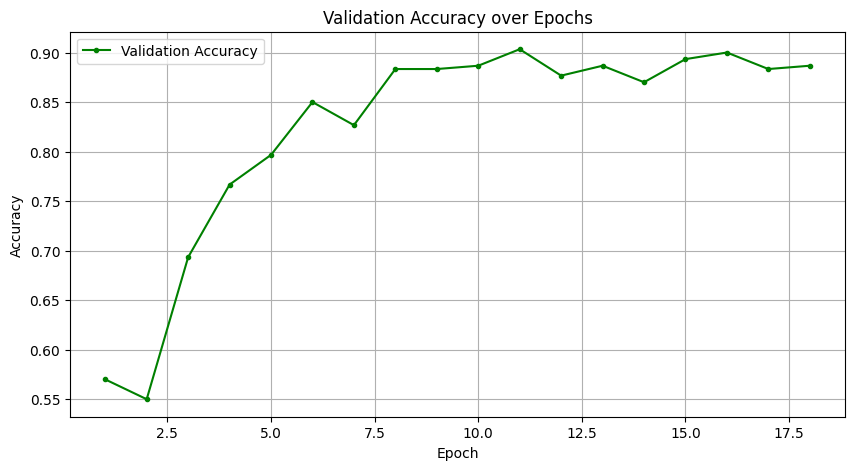

In [21]:
import matplotlib.pyplot as plt

num_epochs_run = len(train_losses) 
epochs = range(1, num_epochs_run + 1) # X-axis data

# Plot 1: Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Training Loss', marker='.')
plt.plot(epochs, val_losses, label='Validation Loss', marker='.')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Accuracy Curve
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green', marker='.')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()